In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Data Discovery

Load Dataset

In [30]:
df_events = pd.read_json('stream_events.jsonl', lines=True)
df_events.head()

,event_id,event_time,user_id,dept,role,device_type,source_ip,asset_id,asset_type,data_classification,action,status,bytes_out,records_accessed,latency_ms,risk_score,label
0,EVT0000001,2026-05-27 12:59:43,U0137,Operations,admin,server,10.10.3.166,cust_db,database,restricted,upload,success,18209,193,95,0,normal
1,EVT0000002,2026-05-27 12:59:53,U0067,Data Science,intern,server,10.10.13.73,public_web,web,public,read,success,36452,280,127,1,normal
2,EVT0000003,2026-05-27 13:00:03,U0121,Sales,admin,laptop,10.10.8.168,cust_db,database,restricted,query,success,196646,508,143,25,normal
3,EVT0000004,2026-05-27 13:00:13,U0064,Sales,manager,mobile,10.10.16.173,data_lake,storage,restricted,download,success,53304,223,104,4,normal
4,EVT0000005,2026-05-27 13:00:23,U0095,Operations,analyst,vpn_gateway,10.10.6.248,crm,saas,confidential,query,success,157538,11252,109,4,normal


In [31]:
df_users = pd.read_csv('users.csv')
df_users.head()

,user_id,employee_id,dept,role,clearance,location,status
0,U0001,E00001,Data Science,analyst,public,Surabaya,active
1,U0002,E00002,HR,manager,public,Surabaya,active
2,U0003,E00003,Legal,analyst,restricted,Jakarta,active
3,U0004,E00004,HR,manager,public,Surabaya,active
4,U0005,E00005,Data Science,admin,restricted,Jakarta,active


In [32]:
df_assets = pd.read_csv('assets.csv')
df_assets.head()

,asset_id,asset_type,data_classification
0,cust_db,database,restricted
1,payroll,database,confidential
2,crm,saas,confidential
3,data_lake,storage,restricted
4,git_repo,code,internal


schema, jumlah baris, missing value, duplicate event_id

In [33]:
print("df_events columns:\n", ", ".join(df_events.columns))
print("\ndf_users columns:\n", ", ".join(df_users.columns))
print("\ndf_assets columns:\n", ", ".join(df_assets.columns))

df_events columns:
 event_id, event_time, user_id, dept, role, device_type, source_ip, asset_id, asset_type, data_classification, action, status, bytes_out, records_accessed, latency_ms, risk_score, label

df_users columns:
 user_id, employee_id, dept, role, clearance, location, status

df_assets columns:
 asset_id, asset_type, data_classification


In [34]:
print("df_events rows:", len(df_events))
print("df_users rows:", len(df_users))
print("df_assets rows:", len(df_assets))

df_events rows: 100000
df_users rows: 150
df_assets rows: 8


In [35]:
print("missing value")

print("\n[df_events]:")
print(df_events.isnull().sum()[df_events.isnull().sum() > 0] if df_events.isnull().sum().sum() > 0 else "Tidak ada missing value")

print("\n[df_users]:")
print(df_users.isnull().sum()[df_users.isnull().sum() > 0] if df_users.isnull().sum().sum() > 0 else "Tidak ada missing value")

print("\n[df_assets]:")
print(df_assets.isnull().sum()[df_assets.isnull().sum() > 0] if df_assets.isnull().sum().sum() > 0 else "Tidak ada missing value")

missing value

[df_events]:
Tidak ada missing value

[df_users]:
Tidak ada missing value

[df_assets]:
Tidak ada missing value


In [36]:
duplicate_count = df_events.duplicated(subset=['event_id']).sum()
print(f"Jumlah baris dengan event_id duplikat: {duplicate_count}")

Jumlah baris dengan event_id duplikat: 0


distribusi action, status, data_classification

=== DISTRIBUSI KOLOM: ACTION ===
                   Count  Percentage (%)
action                                  
read               25675           25.67
login              22678           22.68
query              18532           18.53
download           10306           10.31
logout              8293            8.29
upload              6182            6.18
schema_discovery    5255            5.26
delete              2049            2.05
permission_change   1030            1.03


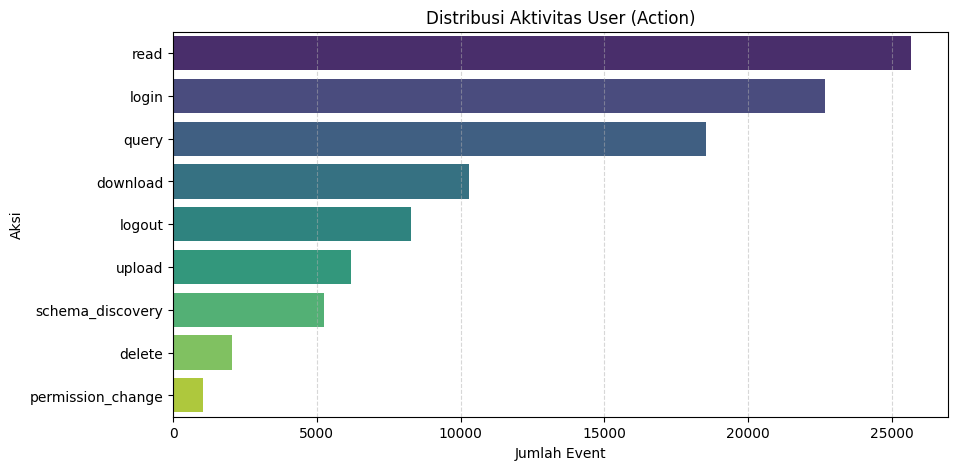

In [37]:
print("=== DISTRIBUSI KOLOM: ACTION ===")
# 1. Tampilkan Tabel Ringkas
df_action = df_events['action'].value_counts().to_frame(name='Count')
df_action['Percentage (%)'] = (df_events['action'].value_counts(normalize=True) * 100).round(2)
print(df_action)

# 2. Visualisasi Bar Plot Horizontal (Cocok untuk kategori yang banyak)
plt.figure(figsize=(10, 5))
sns.countplot(data=df_events, y='action', order=df_events['action'].value_counts().index, palette='viridis')
plt.title('Distribusi Aktivitas User (Action)')
plt.xlabel('Jumlah Event')
plt.ylabel('Aksi')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

=== DISTRIBUSI KOLOM: STATUS ===
         Count  Percentage (%)
status                        
success  89946           89.95
failed   10054           10.05


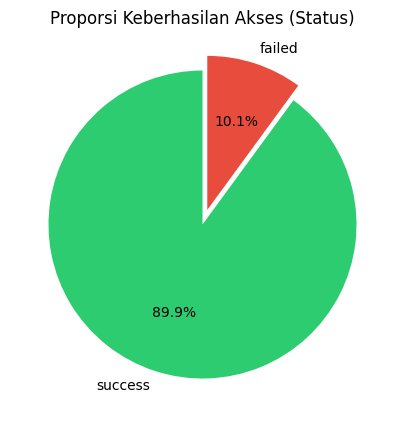

In [38]:
print("=== DISTRIBUSI KOLOM: STATUS ===")
# 1. Tampilkan Tabel Ringkas
df_status = df_events['status'].value_counts().to_frame(name='Count')
df_status['Percentage (%)'] = (df_events['status'].value_counts(normalize=True) * 100).round(2)
print(df_status)

# 2. Visualisasi Pie Chart (Cocok untuk kategori sedikit/biner)
plt.figure(figsize=(5, 5))
df_events['status'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90, explode=(0, 0.1))
plt.title('Proporsi Keberhasilan Akses (Status)')
plt.ylabel('') # Menghilangkan label y otomatis
plt.show()

=== DISTRIBUSI KOLOM: DATA CLASSIFICATION ===
                     Count  Percentage (%)
data_classification                       
internal             37631           37.63
restricted           25011           25.01
confidential         24986           24.99
public               12372           12.37


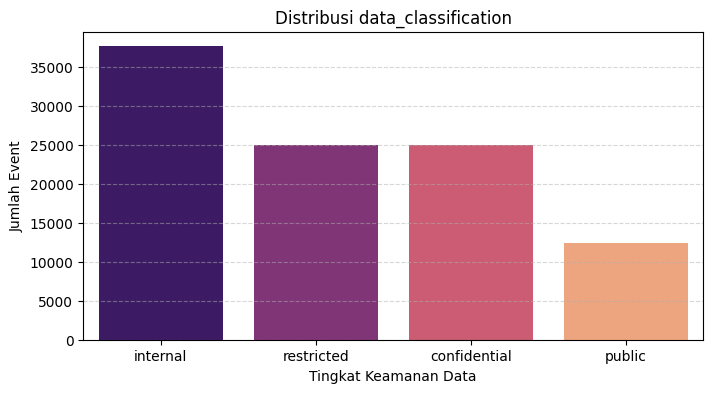

In [39]:
print("=== DISTRIBUSI KOLOM: DATA CLASSIFICATION ===")
# 1. Tampilkan Tabel Ringkas
df_class = df_events['data_classification'].value_counts().to_frame(name='Count')
df_class['Percentage (%)'] = (df_events['data_classification'].value_counts(normalize=True) * 100).round(2)
print(df_class)

# 2. Visualisasi Bar Plot Vertikal
plt.figure(figsize=(8, 4))
sns.countplot(data=df_events, x='data_classification', order=df_events['data_classification'].value_counts().index, palette='magma')
plt.title('Distribusi data_classification')
plt.xlabel('Tingkat Keamanan Data')
plt.ylabel('Jumlah Event')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

top 5 user dan access

In [40]:
top_users = df_events['user_id'].value_counts().head(5).to_frame(name='Jumlah Event')
top_users['Persentase (%)'] = (df_events['user_id'].value_counts(normalize=True).head(5) * 100).round(2)
print(top_users)

         Jumlah Event  Persentase (%)
user_id                              
U0136             734            0.73
U0002             721            0.72
U0037             718            0.72
U0104             717            0.72
U0135             716            0.72


In [41]:
top_assets = df_events['asset_id'].value_counts().head(5).to_frame(name='Jumlah Akses')
top_assets['Persentase (%)'] = (df_events['asset_id'].value_counts(normalize=True).head(5) * 100).round(2)
print(top_assets)

              Jumlah Akses  Persentase (%)
asset_id                                  
payroll              12633           12.63
git_repo             12632           12.63
bi_dashboard         12577           12.58
data_lake            12521           12.52
cust_db              12490           12.49


Data Dictionary ditulis di laporan

In [42]:
# Menampilkan tipe data dan jumlah baris non-null untuk memastikan kesesuaian skema
df_events[['event_id', 'event_time', 'user_id', 'source_ip', 'asset_id', 
           'data_classification', 'action', 'bytes_out', 'risk_score', 'label']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   event_id             100000 non-null  object        
 1   event_time           100000 non-null  datetime64[ns]
 2   user_id              100000 non-null  object        
 3   source_ip            100000 non-null  object        
 4   asset_id             100000 non-null  object        
 5   data_classification  100000 non-null  object        
 6   action               100000 non-null  object        
 7   bytes_out            100000 non-null  int64         
 8   risk_score           100000 non-null  int64         
 9   label                100000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 7.6+ MB


# 2. Data Science

Buat fitur analitik

In [43]:
# 1. Menghitung total event per user (event_per_user)
# Fitur ini menangkap tingkat aktivitas umum pengguna.
feature_total_events = df_events.groupby('user_id').size().to_frame(name='event_per_user')

In [44]:
# 2. Menghitung rasio kegagalan login (failed_login_rate)
# Indikator serangan brute-force atau akun yang terkompromi.
login_events = df_events[df_events['action'] == 'login']
failed_logins = login_events[login_events['status'] == 'failed'].groupby('user_id').size()
total_logins = login_events.groupby('user_id').size()
feature_failed_login_rate = (failed_logins / total_logins).fillna(0).to_frame(name='failed_login_rate')

In [45]:
# 3. Menghitung akumulasi data yang keluar (total_bytes_out)
# Fitur penting untuk mendeteksi pencurian data (data exfiltration) skala besar.
feature_bytes = df_events.groupby('user_id')['bytes_out'].sum().to_frame(name='total_bytes_out')

In [46]:
# 4. Menghitung rasio akses ke aset sensitif berdasarkan clearance level pengguna
df_merged = df_events.merge(df_users[['user_id', 'clearance']], on='user_id', how='left')

# Definisikan kondisi pelanggaran hak akses (Clearance rendah mengakses data tinggi)
# User clearance: public/internal mengidentifikasi aset: restricted/confidential
low_clearance_cond = df_merged['clearance'].isin(['public', 'internal'])
high_asset_cond = df_merged['data_classification'].isin(['restricted', 'confidential'])

# Hitung jumlah akses tidak sah per user
unauthorized_access = df_merged[low_clearance_cond & high_asset_cond].groupby('user_id').size()
total_access = df_merged.groupby('user_id').size()

feature_unauthorized_ratio = (unauthorized_access / total_access).fillna(0).to_frame(name='unauthorized_access_ratio')

In [47]:
# 5. Menghitung rata-rata latensi koneksi (avg_latency)
# Anomali latensi bisa mengindikasikan penggunaan skrip otomasi/bot atau akses via VPN/Tor node jarak jauh.
feature_latency = df_events.groupby('user_id')['latency_ms'].mean().to_frame(name='avg_latency')

In [48]:
df_features = feature_total_events.join([
    feature_failed_login_rate,
    feature_bytes,
    feature_unauthorized_ratio,
    feature_latency
]).fillna(0)

In [49]:
df_features.head(10)

,event_per_user,failed_login_rate,total_bytes_out,unauthorized_access_ratio,avg_latency
user_id,,,,,
U0001,677,0.111111,56159352,0.491876,120.128508
U0002,721,0.102564,57214679,0.524272,119.212205
U0003,639,0.104478,51510027,0.000000,119.348983
U0004,692,0.074713,55255215,0.526012,120.790462
U0005,673,0.124224,55692053,0.000000,117.830609
U0006,686,0.067568,55045871,0.450437,117.813411
U0007,661,0.074830,51591399,0.487141,119.860817
U0008,674,0.062937,53756815,0.000000,119.565282
U0009,696,0.109589,56393378,0.000000,119.952586


EDA

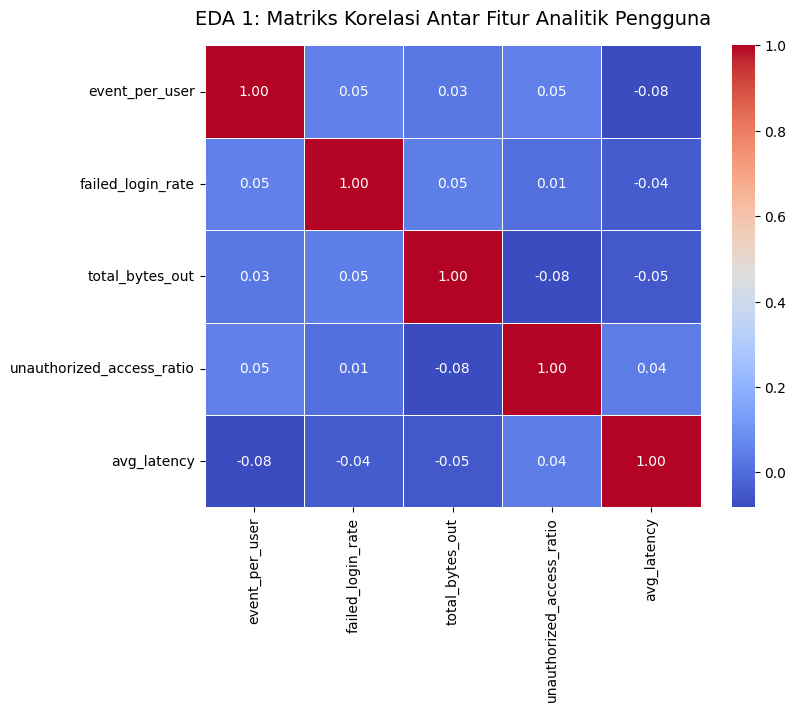

In [50]:
plt.figure(figsize=(8, 6))
# Menghitung matriks korelasi dari dataframe fitur
correlation_matrix = df_features.corr()

# Membuat heatmap interaktif
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('EDA 1: Matriks Korelasi Antar Fitur Analitik Pengguna', fontsize=14, pad=15)
plt.show()

Tidak ada Hubungan linear yang kuat antar fitur

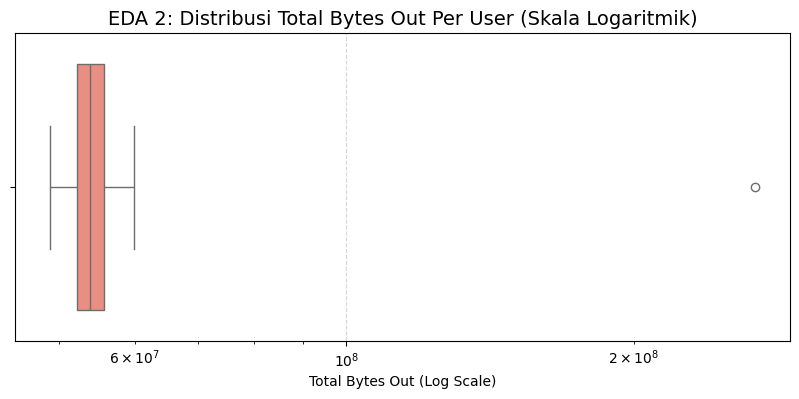

In [56]:
plt.figure(figsize=(10, 4))
# Menggunakan skala logaritmik karena perbedaan data normal vs attack bisa jutaan bytes
sns.boxplot(x=df_features['total_bytes_out'], color='salmon')
plt.xscale('log') 

plt.title('EDA 2: Distribusi Total Bytes Out Per User (Skala Logaritmik)', fontsize=14)
plt.xlabel('Total Bytes Out (Log Scale)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

mayoritas pengguna punya volume data keluar 50-60 MB.
Terlihat 1 titik extreme melebihi 200 MB 

Perilaku ini mencerminkan Skenario A (Eksfiltrasi Data) yang berhasil diisolasi oleh fitur total_bytes_out

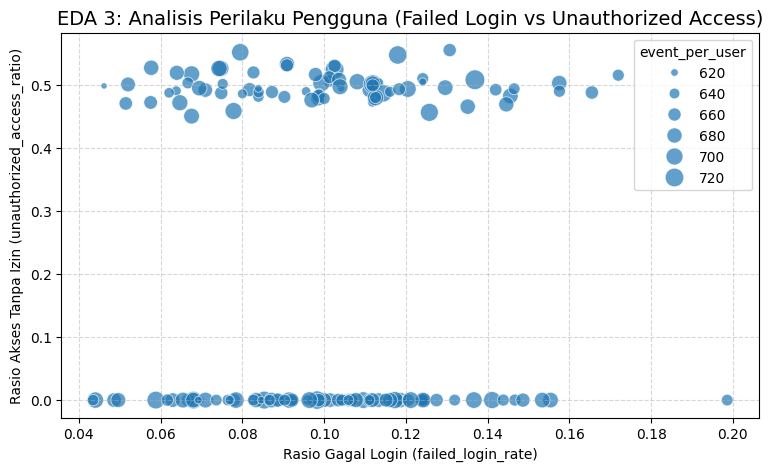

In [54]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df_features, 
    x='failed_login_rate', 
    y='unauthorized_access_ratio', 
    size='event_per_user', 
    sizes=(20, 200),
    alpha=0.7,
    palette='viridis'
)

plt.title('EDA 3: Analisis Perilaku Pengguna (Failed Login vs Unauthorized Access)', fontsize=14)
plt.xlabel('Rasio Gagal Login (failed_login_rate)')
plt.ylabel('Rasio Akses Tanpa Izin (unauthorized_access_ratio)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Mayoritas user memiliki rasio akses tanpa izin sebesar 0%. Mereka tersebar di sepanjang sumbu X dengan tingkat kegagalan login normal (4% hingga 16%), dengan satu outlier operasional mendekati 20%

Terdapat sekelompok pengguna yang memiliki rasio akses tanpa izin yang sangat tinggi, di mana hampir separuh dari total aktivitas mereka (45% sampai 55%) berupa pembacaan aset sensitif yang tidak sesuai dengan clearance level mereka

Kelompok atas secara instan mengonfirmasi keberadaan akun-akun yang terkompromi (Compromised Accounts atau Privilege Abuse). Fakta bahwa mereka memiliki variasi failed_login_rate yang mirip dengan user normal tetapi memiliki unauthorized_access_ratio yang masif menunjukkan bahwa akun ini telah dikendalikan oleh pihak luar atau orang dalam yang menyalahgunakan wewenang.